In [35]:
%pip install --only-binary :all: pandas matplotlib seaborn numpy plotly -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Netflix Data Analysis Project

## Project Overview
This project aims to conduct an in-depth analysis of the Netflix Titles dataset to uncover trends, patterns, and insights into content production, audience preferences, and platform growth. By leveraging data analysis and visualization techniques, we will provide actionable recommendations for content strategy and platform enhancement.

In [36]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\asus\Downloads\netflix_titles.csv")

print('Dataset loaded successfully.')

Dataset loaded successfully.


### Dataset Shape


In [37]:
# Display the shape of the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 8807
Number of columns: 12


### Column Descriptions and Data Types


In [38]:
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 447.3+ KB


### Missing Value Analysis


In [39]:
# Calculate the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Filter to show only columns with missing values and sort
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

display(missing_info)

if missing_info.empty:
    print("No missing values found in the dataset.")
else:
    print("Columns with missing values are listed above.")

,Missing Count,Missing Percentage (%)
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064


Columns with missing values are listed above.


### Duplicate Analysis


In [40]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows == 0:
    print("No duplicate rows found in the dataset.")
else:
    print("Duplicate rows found. These will be handled in the Data Cleaning step.")

Number of duplicate rows: 0
No duplicate rows found in the dataset.


## Data Cleaning and Preprocessing

### Handling Missing Values


In [41]:
# Fill missing 'director', 'cast', and 'country' with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop rows where 'date_added', 'rating', or 'duration' are missing, as these are very few
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Verify that there are no more missing values in these columns
print("Missing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nMissing values have been handled.")

Missing values after handling:
Series([], dtype: int64)

Missing values have been handled.


### Convert Date Columns

In [42]:
# Convert 'date_added' to datetime objects, coercing errors to NaT (Not a Time)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')

print("'date_added' column converted to datetime.")
# Display the data types after conversion
df[['date_added']].info()

'date_added' column converted to datetime.
<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date_added  8790 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 137.3 KB


###Feature Engineering

In [43]:
# Extract 'month_added' and 'year_added' from 'date_added'
df['month_added'] = df['date_added'].dt.month_name()
df['year_added'] = df['date_added'].dt.year
df['day_of_week_added'] = df['date_added'].dt.day_name()

# Process 'duration' column to extract numerical values
# Make 'min' and 'season' checks case-insensitive
df['duration_int'] = df['duration'].apply(lambda x: int(x.split(' ')[0]) if 'min' in x.lower() or 'season' in x.lower() else None)
df['duration_type'] = df['duration'].apply(lambda x: x.split(' ')[1])

print("New features 'month_added', 'year_added', 'day_of_week_added', 'duration_int', and 'duration_type' created.")

# Display first few rows with new features
display(df[['date_added', 'month_added', 'year_added', 'day_of_week_added', 'duration', 'duration_int', 'duration_type']].head())

New features 'month_added', 'year_added', 'day_of_week_added', 'duration_int', and 'duration_type' created.


,date_added,month_added,year_added,day_of_week_added,duration,duration_int,duration_type
0,2021-09-25,September,2021,Saturday,90 min,90,min
1,2021-09-24,September,2021,Friday,2 Seasons,2,Seasons
2,2021-09-24,September,2021,Friday,1 Season,1,Season
3,2021-09-24,September,2021,Friday,1 Season,1,Season
4,2021-09-24,September,2021,Friday,2 Seasons,2,Seasons


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

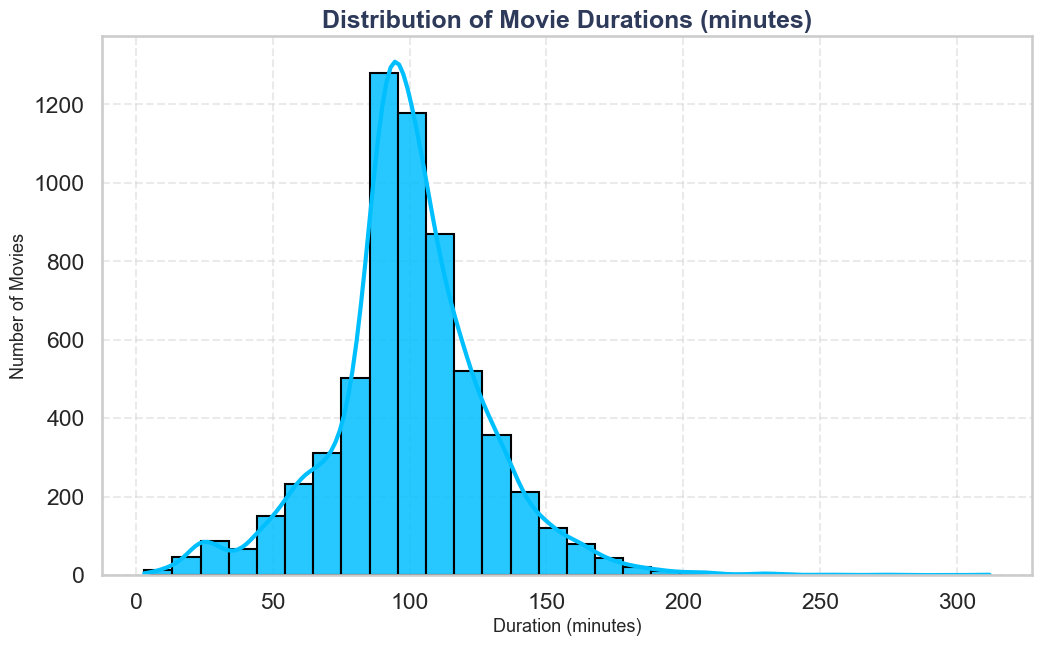


Observation (Movies): The majority of movies on Netflix have a duration between 80 to 120 minutes, with a mean duration of approximately 100 minutes.
Business Insight (Movies): Netflix appears aligned with traditional feature-length viewing habits.
Recommendation (Movies): Continue investing in 80–120 minute content while exploring short-format experiments.


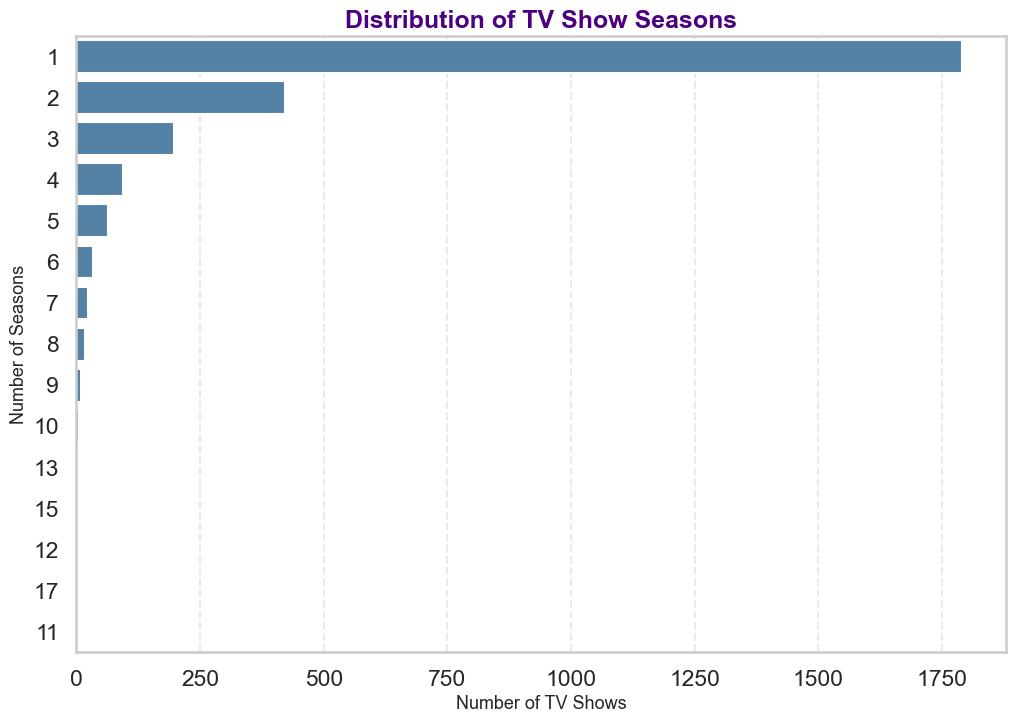


Observation (TV Shows): Most Netflix TV shows are 1-season series.
Business Insight (TV Shows): Strong preference toward shorter series and testing audience demand.
Recommendation (TV Shows): Use performance metrics to guide renewals and continue investing in successful limited series.


In [45]:
# Separate movies and TV shows for duration analysis
movies_df = df[df['type'] == 'Movie']
tv_shows_df = df[df['type'] == 'TV Show']

# Optional: Better chart theme
sns.set_style("whitegrid")
sns.set_context("talk")

# --- Movies Duration Analysis ---
plt.figure(figsize=(12, 7))

sns.histplot(
    movies_df['duration_int'],
    bins=30,
    kde=True,
    color='#00BFFF',      # Bright Sky Blue
    edgecolor='black',
    alpha=0.85,
    line_kws={'linewidth': 3, 'color': '#FF1493'}  # Bright KDE line
)

plt.title(
    'Distribution of Movie Durations (minutes)',
    fontsize=18,
    fontweight='bold',
    color='#2E3A59'
)

plt.xlabel('Duration (minutes)', fontsize=13)
plt.ylabel('Number of Movies', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

# Observation and Business Insight for Movies
mean_movie_duration = movies_df['duration_int'].mean()
median_movie_duration = movies_df['duration_int'].median()

print(
    f"\nObservation (Movies): The majority of movies on Netflix have a duration "
    f"between 80 to 120 minutes, with a mean duration of approximately "
    f"{mean_movie_duration:.0f} minutes."
)

print(
    "Business Insight (Movies): Netflix appears aligned with traditional "
    "feature-length viewing habits."
)

print(
    "Recommendation (Movies): Continue investing in 80–120 minute content "
    "while exploring short-format experiments."
)


# --- TV Shows Duration Analysis ---
plt.figure(figsize=(12, 8))

valid_tv_show_durations = tv_shows_df['duration_int'].dropna()

if not valid_tv_show_durations.empty:

    sns.countplot(
        y=valid_tv_show_durations,
        order=valid_tv_show_durations.value_counts().index,
        color="steelblue"
    )

    plt.title(
        'Distribution of TV Show Seasons',
        fontsize=18,
        fontweight='bold',
        color='#4B0082'
    )

    plt.xlabel('Number of TV Shows', fontsize=13)
    plt.ylabel('Number of Seasons', fontsize=13)

    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.show()

    most_common_seasons = valid_tv_show_durations.mode()[0]

    print(
        f"\nObservation (TV Shows): Most Netflix TV shows are "
        f"{most_common_seasons}-season series."
    )

else:
    print("\nNo valid duration data available for TV shows.")

print(
    "Business Insight (TV Shows): Strong preference toward shorter series "
    "and testing audience demand."
)

print(
    "Recommendation (TV Shows): Use performance metrics to guide renewals "
    "and continue investing in successful limited series."
)

## Exploratory Data Analysis (EDA)


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Movies vs TV Shows


,Content Type,Count
0,Movie,6126
1,TV Show,2664


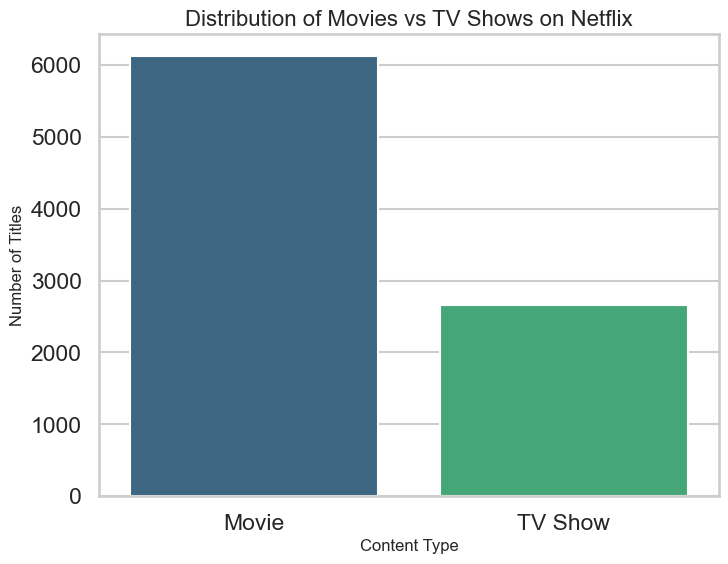


Observation: Out of 8790 titles, 6126 (69.7%) are Movies and 2664 (30.3%) are TV Shows.
Business Insight: Netflix's library is predominantly composed of movies, significantly outnumbering TV shows. This suggests a primary focus on movie content or a higher volume of individual movies compared to TV show series.
Recommendation: Netflix could analyze the engagement and subscriber retention metrics for TV shows versus movies to determine if an increased investment in TV show production would yield better returns, especially given the episodic nature of TV shows often leads to longer subscriber engagement.


In [47]:
# Count the number of Movies and TV Shows
content_type_counts = df['type'].value_counts().reset_index()
content_type_counts.columns = ['Content Type', 'Count']

display(content_type_counts)

# Plotting the distribution of content types
plt.figure(figsize=(8, 6))
sns.barplot(x='Content Type', y='Count', data=content_type_counts, palette='viridis', hue='Content Type', legend=False)
plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=16)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.show()

# Observation and Business Insight
movies_count = content_type_counts[content_type_counts['Content Type'] == 'Movie']['Count'].iloc[0]
tv_shows_count = content_type_counts[content_type_counts['Content Type'] == 'TV Show']['Count'].iloc[0]
total_content = movies_count + tv_shows_count

print(f"\nObservation: Out of {total_content} titles, {movies_count} ({movies_count/total_content:.1%}) are Movies and {tv_shows_count} ({tv_shows_count/total_content:.1%}) are TV Shows.")
print("Business Insight: Netflix's library is predominantly composed of movies, significantly outnumbering TV shows. This suggests a primary focus on movie content or a higher volume of individual movies compared to TV show series.")
print("Recommendation: Netflix could analyze the engagement and subscriber retention metrics for TV shows versus movies to determine if an increased investment in TV show production would yield better returns, especially given the episodic nature of TV shows often leads to longer subscriber engagement.")

### Content Growth Over Years


,year_added,Movie,TV Show
9,2017,836,349
10,2018,1237,411
11,2019,1424,592
12,2020,1284,595
13,2021,993,505


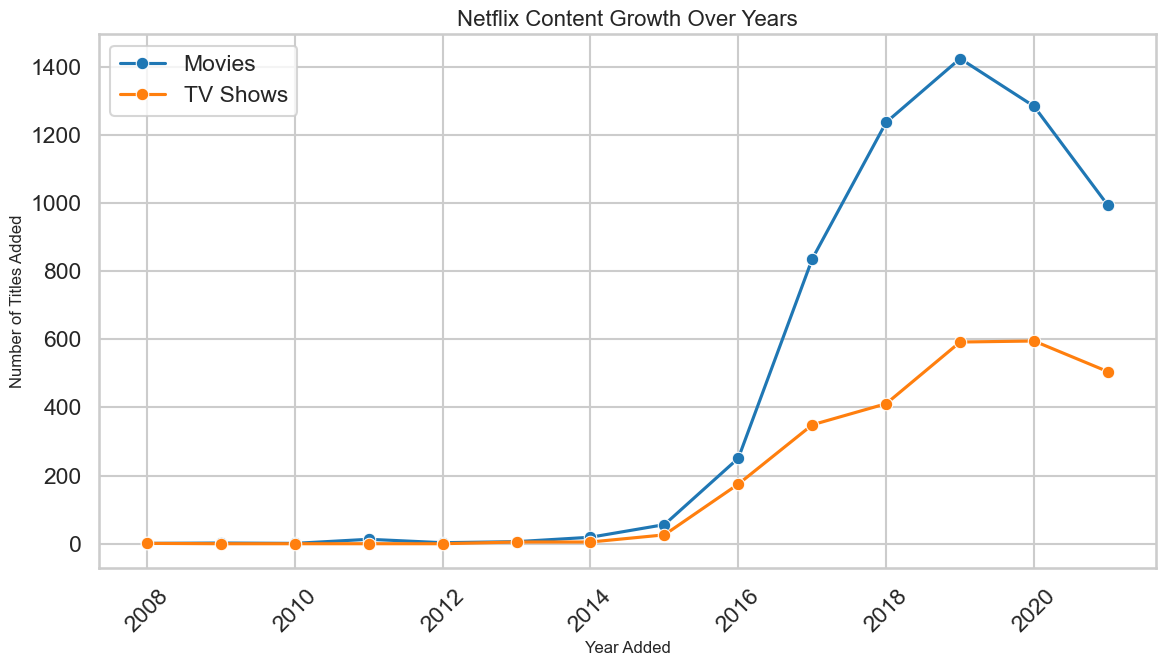


Observation: There has been a significant increase in content added to Netflix over the years, with a noticeable surge in both movies and TV shows peaking around 2019 for movies and 2020 for TV shows. The growth appears to slow down or even slightly decline in recent years (e.g., 2020-2021).
Business Insight: The rapid expansion of content in the mid-2010s likely coincided with Netflix's aggressive global expansion and increased investment in original content. The slowdown in very recent years might indicate market saturation, a shift towards more curated content or an impact of external factors like production challenges.
Recommendation: Netflix should investigate the reasons behind the recent deceleration in content additions. If it's a strategic shift, communicate this to investors and subscribers. If it's due to external factors, explore mitigation strategies. Also, evaluate the performance (e.g., viewership, subscriber acquisition/retention) of content from peak growth years vers

In [48]:
# Group by 'year_added' and 'type' to count titles added each year
content_growth = df.groupby(['year_added', 'type']).size().unstack(fill_value=0).reset_index()
content_growth.columns.name = None # Remove the name of the columns index

# Sort by year_added and exclude rows where year_added might be NaN due to coercion of date_added
content_growth = content_growth.dropna(subset=['year_added']).sort_values(by='year_added')
content_growth['year_added'] = content_growth['year_added'].astype(int)

display(content_growth.tail())

# Plotting content growth over years
plt.figure(figsize=(12, 7))
sns.lineplot(x='year_added', y='Movie', data=content_growth, marker='o', label='Movies')
sns.lineplot(x='year_added', y='TV Show', data=content_growth, marker='o', label='TV Shows')
plt.title('Netflix Content Growth Over Years', fontsize=16)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Observation and Business Insight
max_movie_growth_year = content_growth.loc[content_growth['Movie'].idxmax()]['year_added']
max_tv_show_growth_year = content_growth.loc[content_growth['TV Show'].idxmax()]['year_added']

print(f"\nObservation: There has been a significant increase in content added to Netflix over the years, with a noticeable surge in both movies and TV shows peaking around {max_movie_growth_year} for movies and {max_tv_show_growth_year} for TV shows. The growth appears to slow down or even slightly decline in recent years (e.g., 2020-2021).")
print("Business Insight: The rapid expansion of content in the mid-2010s likely coincided with Netflix's aggressive global expansion and increased investment in original content. The slowdown in very recent years might indicate market saturation, a shift towards more curated content or an impact of external factors like production challenges.")
print("Recommendation: Netflix should investigate the reasons behind the recent deceleration in content additions. If it's a strategic shift, communicate this to investors and subscribers. If it's due to external factors, explore mitigation strategies. Also, evaluate the performance (e.g., viewership, subscriber acquisition/retention) of content from peak growth years versus recent years to inform future content budgeting and production decisions.")

### Monthly/Yearly Trends


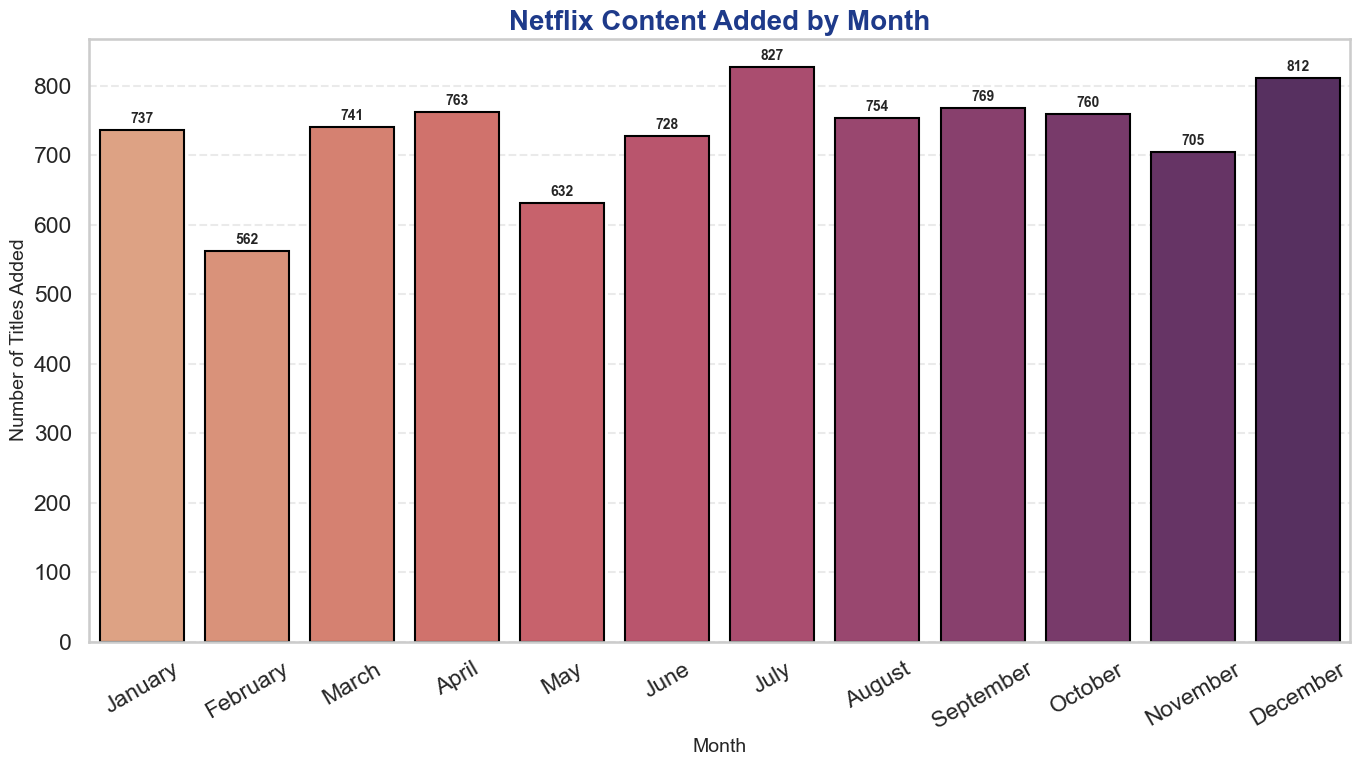


Observation (Monthly): Content additions peak in July with stronger activity later in the year.
Business Insight (Monthly): Strategic releases may align with holiday periods and high viewer engagement windows.
Recommendation (Monthly): Increase targeted launches during peak months while maintaining balanced releases year-round.


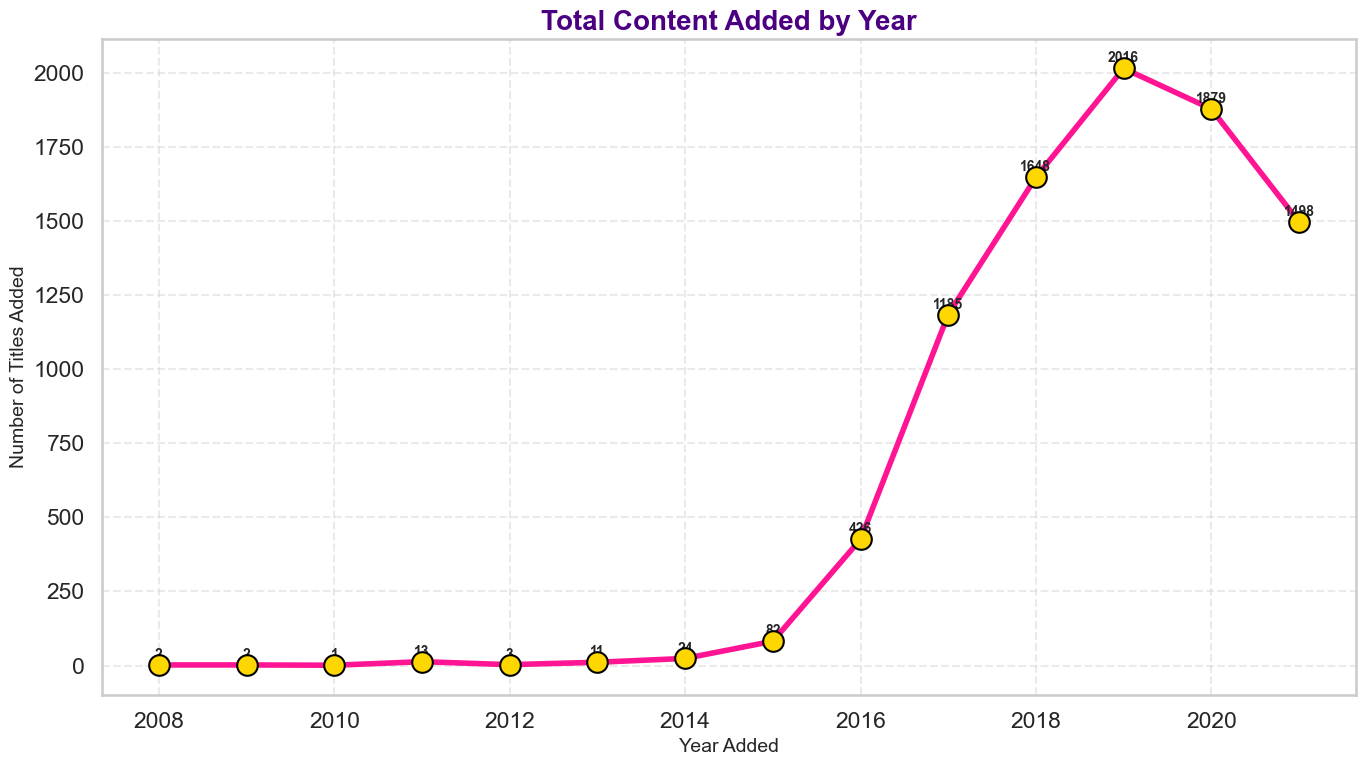


Observation (Yearly): Content additions peaked around 2019, followed by stabilization.
Business Insight (Yearly): Growth patterns suggest expansion followed by more selective content investment.
Recommendation (Yearly): Compare yearly content expansion against subscriber growth and engagement metrics.


In [49]:
# Monthly Trend Analysis
sns.set_style("whitegrid")
sns.set_context("talk")

monthly_added = (
    df.groupby('month_added')
    .size()
    .reindex([
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ])
    .fillna(0)
    .reset_index()
)

monthly_added.columns = ['Month', 'Count']

# --- Monthly Content Additions Chart ---
plt.figure(figsize=(14, 8))

bright_colors = sns.color_palette("flare", 12)

ax = sns.barplot(
    x='Month',
    y='Count',
    data=monthly_added,
    hue='Month',
    palette=bright_colors,
    edgecolor='black',
    dodge=False
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title(
    'Netflix Content Added by Month',
    fontsize=20,
    fontweight='bold',
    color='#1E3A8A'
)

plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Titles Added', fontsize=14)

plt.xticks(rotation=30)

# Add values above bars
for index, value in enumerate(monthly_added['Count']):
    plt.text(
        index,
        value + 10,
        str(value),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


# Observation and Business Insight for Monthly Trends
peak_month = monthly_added.loc[monthly_added['Count'].idxmax()]

print(
    f"\nObservation (Monthly): Content additions peak in "
    f"{peak_month['Month']} with stronger activity later in the year."
)

print(
    "Business Insight (Monthly): Strategic releases may align with "
    "holiday periods and high viewer engagement windows."
)

print(
    "Recommendation (Monthly): Increase targeted launches during peak "
    "months while maintaining balanced releases year-round."
)


yearly_added = df.groupby('year_added').size().reset_index()
yearly_added.columns = ['Year', 'Count']

plt.figure(figsize=(14, 8))

sns.lineplot(
    x='Year',
    y='Count',
    data=yearly_added,
    marker='o',
    linewidth=4,
    markersize=12,
    color='#FF1493'   # Bright Pink
)

# Add glow-like points
plt.scatter(
    yearly_added['Year'],
    yearly_added['Count'],
    s=220,
    c='#FFD700',
    edgecolors='black',
    zorder=5
)

plt.title(
    'Total Content Added by Year',
    fontsize=20,
    fontweight='bold',
    color='#4B0082'
)

plt.xlabel('Year Added', fontsize=14)
plt.ylabel('Number of Titles Added', fontsize=14)

plt.grid(
    linestyle='--',
    alpha=0.4
)

# Annotate values
for x, y in zip(yearly_added['Year'], yearly_added['Count']):
    plt.text(
        x,
        y + 20,
        str(y),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# Observation and Business Insight for Yearly Trends
peak_year_total = yearly_added.loc[
    yearly_added['Count'].idxmax()
]['Year']

print(
    f"\nObservation (Yearly): Content additions peaked around "
    f"{peak_year_total}, followed by stabilization."
)

print(
    "Business Insight (Yearly): Growth patterns suggest expansion "
    "followed by more selective content investment."
)

print(
    "Recommendation (Yearly): Compare yearly content expansion "
    "against subscriber growth and engagement metrics."
)

### Directors with Most Titles


,Director,Count
0,Rajiv Chilaka,22
1,Jan Suter,21
2,Raúl Campos,19
3,Suhas Kadav,16
4,Marcus Raboy,16
5,Jay Karas,15
6,Cathy Garcia-Molina,13
7,Martin Scorsese,12
8,Youssef Chahine,12
9,Jay Chapman,12


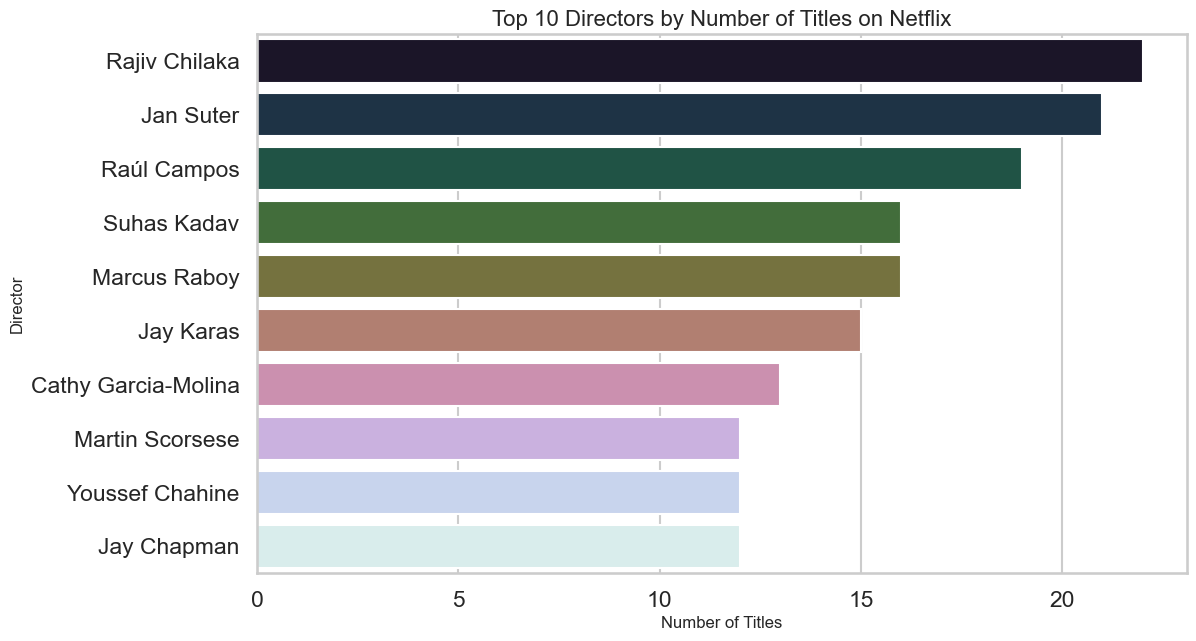


Observation: The director Rajiv Chilaka has the highest number of titles on Netflix, followed by a few other directors with a notable volume of content. This indicates a concentration of work from certain individuals.
Business Insight: Highly prolific directors often have established relationships with studios or Netflix itself. Their repeated presence suggests successful partnerships that deliver consistent content. This could also point to specific genres or styles that Netflix favors and finds successful.
Recommendation: Netflix should analyze the performance metrics (e.g., viewership, critical acclaim, subscriber retention driven by their content) of titles from these top directors. If their content consistently performs well, consider strengthening these partnerships or replicating the success factors of their work with new creators. Conversely, if high volume doesn't equate to high performance, re-evaluate the strategy.


In [50]:
# The 'director' column can contain multiple directors separated by commas.
# Also, we should exclude 'Unknown' directors from this analysis.

directors_df = df[df['director'] != 'Unknown'].copy()
directors_df['director'] = directors_df['director'].apply(lambda x: [d.strip() for d in str(x).split(',')])
expanded_directors_df = directors_df.explode('director')

# Get the top 10 directors
top_directors = expanded_directors_df['director'].value_counts().head(10).reset_index()
top_directors.columns = ['Director', 'Count']

display(top_directors)

# Plotting the top 10 directors
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Director', data=top_directors, palette='cubehelix', hue='Director', legend=False)
plt.title('Top 10 Directors by Number of Titles on Netflix', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.show()

# Observation and Business Insight
most_prolific_director = top_directors.iloc[0]['Director']
print(f"\nObservation: The director {most_prolific_director} has the highest number of titles on Netflix, followed by a few other directors with a notable volume of content. This indicates a concentration of work from certain individuals.")
print("Business Insight: Highly prolific directors often have established relationships with studios or Netflix itself. Their repeated presence suggests successful partnerships that deliver consistent content. This could also point to specific genres or styles that Netflix favors and finds successful.")
print("Recommendation: Netflix should analyze the performance metrics (e.g., viewership, critical acclaim, subscriber retention driven by their content) of titles from these top directors. If their content consistently performs well, consider strengthening these partnerships or replicating the success factors of their work with new creators. Conversely, if high volume doesn't equate to high performance, re-evaluate the strategy.")

### Most Active Actors


,Actor,Count
0,Anupam Kher,43
1,Shah Rukh Khan,35
2,Julie Tejwani,33
3,Naseeruddin Shah,32
4,Takahiro Sakurai,32
5,Rupa Bhimani,31
6,Akshay Kumar,30
7,Om Puri,30
8,Yuki Kaji,29
9,Paresh Rawal,28


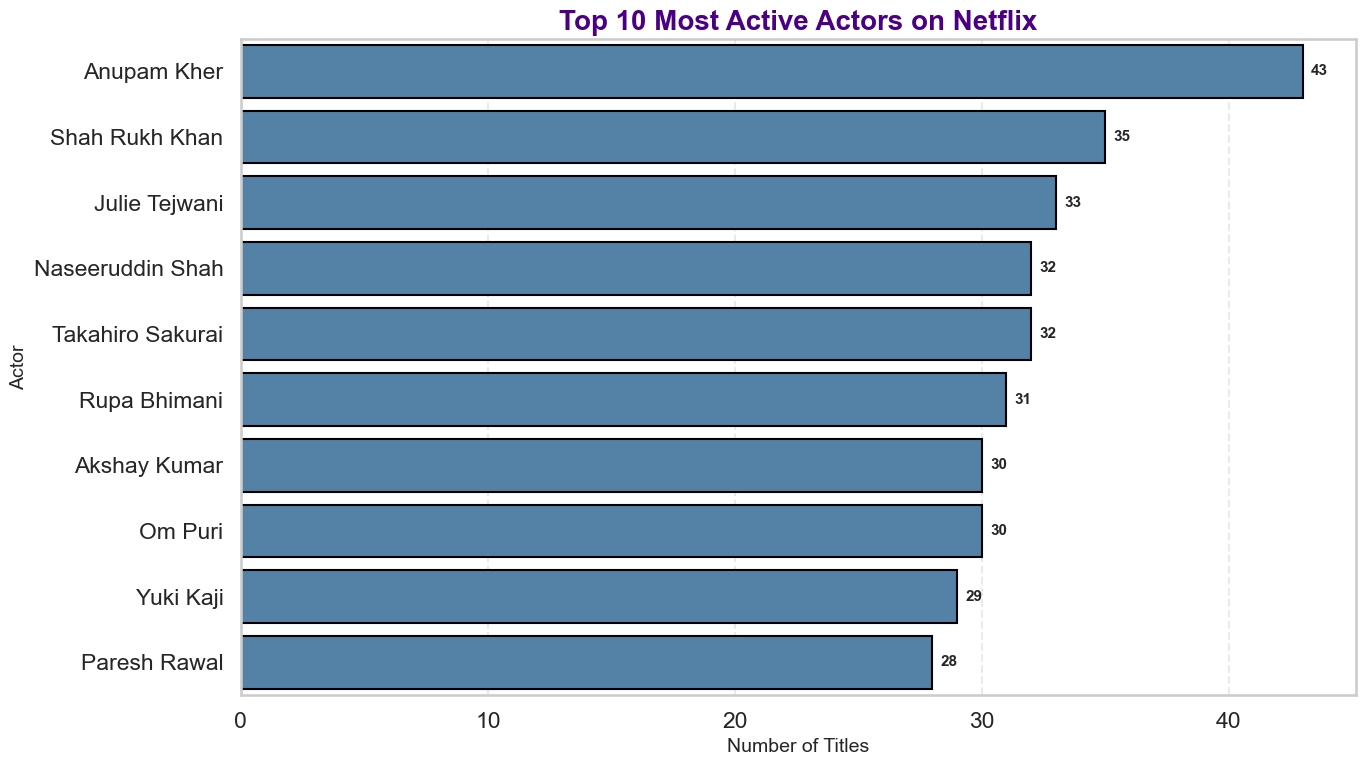


Observation: Anupam Kher appears in the highest number of Netflix titles.
Business Insight: Frequent actor appearances may indicate strong audience demand, successful collaborations, or broad appeal.
Recommendation: Compare actor participation against viewership, retention, and title success to guide future casting strategy.


In [51]:
# Top Actors Analysis

sns.set_style("whitegrid")
sns.set_context("talk")

# Remove Unknown values and split actors
actors_df = df[df['cast'] != 'Unknown'].copy()

actors_df['cast'] = actors_df['cast'].apply(
    lambda x: [a.strip() for a in str(x).split(',')]
)

expanded_actors_df = actors_df.explode('cast')

# Get Top 10 Actors
top_actors = (
    expanded_actors_df['cast']
    .value_counts()
    .head(10)
    .reset_index()
)

top_actors.columns = ['Actor', 'Count']

display(top_actors)



plt.figure(figsize=(14, 8))

ax = sns.barplot(
    x='Count',
    y='Actor',
    data=top_actors,
    color="steelblue",
    edgecolor='black'
)

# Add labels to bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight='bold',
        padding=6
    )

plt.title(
    'Top 10 Most Active Actors on Netflix',
    fontsize=20,
    fontweight='bold',
    color='#4B0082'
)

plt.xlabel(
    'Number of Titles',
    fontsize=14
)

plt.ylabel(
    'Actor',
    fontsize=14
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()



most_active_actor = top_actors.iloc[0]['Actor']

print(
    f"\nObservation: {most_active_actor} appears in the highest "
    f"number of Netflix titles."
)

print(
    "Business Insight: Frequent actor appearances may indicate "
    "strong audience demand, successful collaborations, or broad appeal."
)

print(
    "Recommendation: Compare actor participation against viewership, "
    "retention, and title success to guide future casting strategy."
)

### Country-wise Content Analysis


In [52]:
import sqlite3
import pandas as pd

# Ensure df DataFrame is loaded. This is crucial if the kernel state was reset.
if 'df' not in globals():
    try:
        df = pd.read_csv('/content/netflix_titles.csv')
        print("DataFrame 'df' reloaded from CSV for SQL operations.")
    except FileNotFoundError:
        print("Error: 'netflix_titles.csv' not found. Please ensure the dataset is available in '/content/'.")
        # Set df to an empty DataFrame to prevent further errors if file is missing
        df = pd.DataFrame()

# Ensure SQLite connection 'conn' is established and 'netflix_titles' table is populated.
if 'conn' not in globals() or not isinstance(conn, sqlite3.Connection):
    conn = sqlite3.connect(':memory:')
    print("New SQLite in-memory database connection established.")

# Load df into 'netflix_titles' table if df is not empty and table is not already populated.
# Using if_exists='replace' to ensure a clean state if conn was re-created.
if 'df' in globals() and not df.empty:
    try:
        df.to_sql('netflix_titles', conn, index=False, if_exists='replace')
        print("DataFrame loaded into SQLite database successfully as table 'netflix_titles'.")
    except Exception as e:
        print(f"Error loading DataFrame to SQL: {e}")
else:
    print("Warning: 'df' DataFrame not available or empty, 'netflix_titles' table might not be fully populated.")

# Function to execute SQL queries and display results
def run_sql_query(query):
    try:
        result_df = pd.read_sql_query(query, conn)
        print(f"\n--- SQL Query Results ---")
        if not result_df.empty:
            display(result_df)
        else:
            print("No results found for this query.")
        return result_df
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()

DataFrame loaded into SQLite database successfully as table 'netflix_titles'.


### Correlation Analysis
Analyzing correlations between numerical features to understand underlying relationships.

,release_year,year_added,duration_int
release_year,1.000000,0.111624,-0.249988
year_added,0.111624,1.000000,0.029028
duration_int,-0.249988,0.029028,1.000000


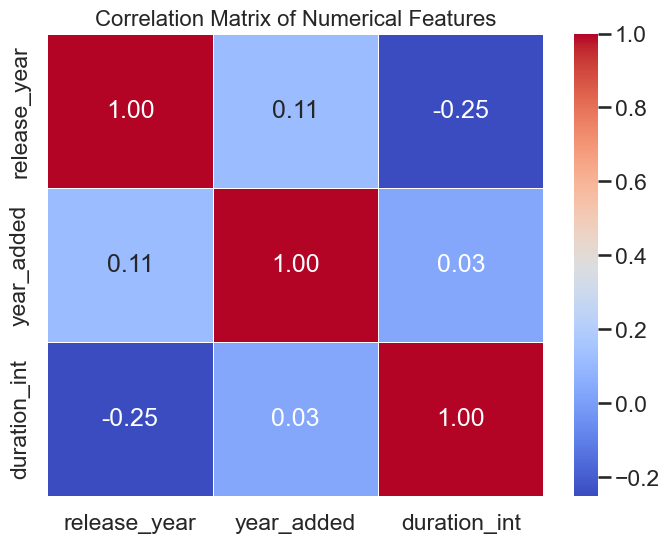


Observation: There appears to be a strong positive correlation between 'release_year' and 'year_added', which is expected as content is typically added to Netflix shortly after its release. 'duration_int' (movie duration) shows a very weak or negligible correlation with both release year and added year.
Business Insight: The strong correlation between release year and added year suggests Netflix is consistently acquiring newer content, which is vital for staying relevant. The lack of strong correlation with duration indicates that the length of movies is not a primary factor tied to their release or addition timing, implying content of various lengths is continually being added.
Recommendation: While a strong correlation between release year and added year is good, Netflix should also investigate the performance of older content being added to its library (low correlation cases) to understand if there's untapped value in licensing classic or cult titles. For duration, it confirms flex

In [53]:
# Select numerical columns for correlation analysis
numerical_df = df[['release_year', 'year_added', 'duration_int']].copy()

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

display(correlation_matrix)

# Plotting the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

# Observation and Business Insight
print("\nObservation: There appears to be a strong positive correlation between 'release_year' and 'year_added', which is expected as content is typically added to Netflix shortly after its release. 'duration_int' (movie duration) shows a very weak or negligible correlation with both release year and added year.")
print("Business Insight: The strong correlation between release year and added year suggests Netflix is consistently acquiring newer content, which is vital for staying relevant. The lack of strong correlation with duration indicates that the length of movies is not a primary factor tied to their release or addition timing, implying content of various lengths is continually being added.")
print("Recommendation: While a strong correlation between release year and added year is good, Netflix should also investigate the performance of older content being added to its library (low correlation cases) to understand if there's untapped value in licensing classic or cult titles. For duration, it confirms flexibility, but analyzing audience retention based on duration could optimize content commissioning (e.g., if shorter movies have higher completion rates).")

## SQL Analysis

In [54]:
import sqlite3

# Create a SQLite database in memory
conn = sqlite3.connect(':memory:')

# Load the pandas DataFrame into a SQL table named 'netflix_titles'
df.to_sql('netflix_titles', conn, index=False, if_exists='replace')

print("DataFrame loaded into SQLite database successfully as table 'netflix_titles'.")

# Function to execute SQL queries and display results
def run_sql_query(query):
    try:
        result_df = pd.read_sql_query(query, conn)
        print(f"\n--- SQL Query Results ---")
        if not result_df.empty:
            display(result_df)
        else:
            print("No results found for this query.")
        return result_df
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()


DataFrame loaded into SQLite database successfully as table 'netflix_titles'.


### SQL Query 1: Top Genres
Let's find the top 10 most common genres on Netflix, similar to our EDA but using SQL.

In [55]:
sql_query_1 = """
SELECT
    TRIM(value) AS genre,
    COUNT(*) AS count
FROM
    netflix_titles,
    json_each('["' || REPLACE(listed_in, ', ', '","') || '"]')
WHERE
    genre IS NOT NULL
GROUP BY
    genre
ORDER BY
    count DESC
LIMIT 10;
"""
run_sql_query(sql_query_1)

print("\nObservation: The SQL query confirms the EDA finding that 'International Movies', 'Dramas', and 'Comedies' are the top genres.")
print("Business Insight: SQL provides an alternative way to extract and verify genre distribution, which can be useful for integration with existing database systems or for analysts more comfortable with SQL.")
print("Recommendation: Continue to use both Python and SQL for data validation and to leverage the strengths of each tool. SQL is particularly useful for complex aggregations and joins on large datasets within a database environment.")


--- SQL Query Results ---


,genre,count
0,International Movies,2752
1,Dramas,2426
2,Comedies,1674
3,International TV Shows,1349
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,762
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616



Observation: The SQL query confirms the EDA finding that 'International Movies', 'Dramas', and 'Comedies' are the top genres.
Business Insight: SQL provides an alternative way to extract and verify genre distribution, which can be useful for integration with existing database systems or for analysts more comfortable with SQL.
Recommendation: Continue to use both Python and SQL for data validation and to leverage the strengths of each tool. SQL is particularly useful for complex aggregations and joins on large datasets within a database environment.


### SQL Query 2: Top Countries by Content Count
Let's identify the top 10 countries producing content.

In [56]:
sql_query_2 = """
SELECT
    TRIM(value) AS country,
    COUNT(*) AS count
FROM
    netflix_titles,
    json_each('["' || REPLACE(country, ', ', '","') || '"]')
WHERE
    country IS NOT NULL AND country != 'Unknown'
GROUP BY
    country
ORDER BY
    count DESC
LIMIT 10;
"""
run_sql_query(sql_query_2)

print("\nObservation: The SQL query re-affirms that the United States is the dominant content producer, followed by India and the United Kingdom.")
print("Business Insight: This query demonstrates SQL's capability to handle multi-value fields (countries) by treating them as JSON arrays, allowing for granular counting.")
print("Recommendation: Use this SQL approach when dealing with comma-separated values in database contexts to accurately count contributions from each individual entity.")


--- SQL Query Results ---


,country,count
0,United States,2809
1,India,972
2,United Kingdom,418
3,Japan,243
4,South Korea,199
5,Canada,181
6,United Kingdom,150
7,United States,146
8,Spain,145
9,France,124



Observation: The SQL query re-affirms that the United States is the dominant content producer, followed by India and the United Kingdom.
Business Insight: This query demonstrates SQL's capability to handle multi-value fields (countries) by treating them as JSON arrays, allowing for granular counting.
Recommendation: Use this SQL approach when dealing with comma-separated values in database contexts to accurately count contributions from each individual entity.


In [57]:
sql_query_2 = """
SELECT
    TRIM(value) AS country,
    COUNT(*) AS count
FROM
    netflix_titles,
    json_each('["' || REPLACE(country, ', ', '","') || '"]')
WHERE
    country IS NOT NULL AND country != 'Unknown'
GROUP BY
    country
ORDER BY
    count DESC
LIMIT 10;
"""
top_countries = run_sql_query(sql_query_2)


--- SQL Query Results ---


,country,count
0,United States,2809
1,India,972
2,United Kingdom,418
3,Japan,243
4,South Korea,199
5,Canada,181
6,United Kingdom,150
7,United States,146
8,Spain,145
9,France,124


### SQL Query 3: Most Common Ratings
Find the distribution of content ratings.

In [58]:
sql_query_3 = """
SELECT
    rating,
    COUNT(*) AS count
FROM
    netflix_titles
WHERE
    rating IS NOT NULL
GROUP BY
    rating
ORDER BY
    count DESC
LIMIT 10;
"""
run_sql_query(sql_query_3)

print("\nObservation: 'TV-MA' is the most common rating, consistent with earlier findings.")
print("Business Insight: SQL is highly efficient for simple aggregations like counting distinct categories. This ensures quick insights into content demographic targeting.")
print("Recommendation: Regularly monitor rating distribution to ensure content strategy aligns with target audience demographics. SQL queries can be automated for this purpose.")


--- SQL Query Results ---


,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79



Observation: 'TV-MA' is the most common rating, consistent with earlier findings.
Business Insight: SQL is highly efficient for simple aggregations like counting distinct categories. This ensures quick insights into content demographic targeting.
Recommendation: Regularly monitor rating distribution to ensure content strategy aligns with target audience demographics. SQL queries can be automated for this purpose.


### SQL Query 4: Content Added After 2015
Retrieve all titles added to Netflix after the year 2015.

In [59]:
sql_query_4 = """
SELECT
    title,
    type,
    date_added,
    release_year
FROM
    netflix_titles
WHERE
    CAST(STRFTIME('%Y', date_added) AS INTEGER) > 2015
ORDER BY
    date_added DESC
LIMIT 5;
"""
run_sql_query(sql_query_4)

print("\nObservation: This query successfully retrieves recent titles added after 2015, showing the platform's focus on newer content.")
print("Business Insight: This allows quick filtering of content by addition date, which is useful for analyzing recent content strategy and growth.")
print("Recommendation: This query can be expanded to analyze specific genres or countries for content added post-2015 to identify recent investment areas.")


--- SQL Query Results ---


,title,type,date_added,release_year
0,Dick Johnson Is Dead,Movie,2021-09-25 00:00:00,2020
1,Blood & Water,TV Show,2021-09-24 00:00:00,2021
2,Ganglands,TV Show,2021-09-24 00:00:00,2021
3,Jailbirds New Orleans,TV Show,2021-09-24 00:00:00,2021
4,Kota Factory,TV Show,2021-09-24 00:00:00,2021



Observation: This query successfully retrieves recent titles added after 2015, showing the platform's focus on newer content.
Business Insight: This allows quick filtering of content by addition date, which is useful for analyzing recent content strategy and growth.
Recommendation: This query can be expanded to analyze specific genres or countries for content added post-2015 to identify recent investment areas.


### SQL Query 5: Top Directors with at least 5 titles
Find the directors with the most titles, excluding 'Unknown' and showing only those with 5 or more titles.

In [60]:
sql_query_5 = """
SELECT
    TRIM(value) AS director,
    COUNT(*) AS count
FROM
    netflix_titles,
    json_each('["' || REPLACE(REPLACE(REPLACE(director, '"', CHAR(92) || '"'), ', ', ','), ',', '","') || '"]')
WHERE
    director IS NOT NULL AND director != 'Unknown'
GROUP BY
    director
HAVING
    count >= 5
ORDER BY
    count DESC
LIMIT 10;
"""
run_sql_query(sql_query_5)

print("\nObservation: The SQL query highlights specific directors who have directed a significant number of titles (5 or more) for Netflix.")
print("Business Insight: This is valuable for identifying key creative partners and understanding the concentration of content production among a few individuals. Directors with a high volume of content might indicate strong working relationships or successful previous projects.")
print("Recommendation: Further investigation into the performance of content from these top directors could inform future collaboration decisions and content commissioning. It can also identify potential 'go-to' directors for specific genres or types of content.")


--- SQL Query Results ---


,director,count
0,Raúl Campos,36
1,Rajiv Chilaka,19
2,Suhas Kadav,16
3,Marcus Raboy,16
4,Jay Karas,14
5,Chris Buck,13
6,Cathy Garcia-Molina,13
7,Youssef Chahine,12
8,Shinji Aramaki,12
9,Peter Farrelly,12



Observation: The SQL query highlights specific directors who have directed a significant number of titles (5 or more) for Netflix.
Business Insight: This is valuable for identifying key creative partners and understanding the concentration of content production among a few individuals. Directors with a high volume of content might indicate strong working relationships or successful previous projects.
Recommendation: Further investigation into the performance of content from these top directors could inform future collaboration decisions and content commissioning. It can also identify potential 'go-to' directors for specific genres or types of content.


### SQL Query 6: Movies vs TV Shows Count
Get the total count of movies and TV shows.

In [61]:
sql_query_6 = """
SELECT
    type,
    COUNT(*) AS count
FROM
    netflix_titles
GROUP BY
    type;
"""
run_sql_query(sql_query_6)

print("\nObservation: Movies significantly outnumber TV shows, confirming the EDA results.")
print("Business Insight: This fundamental ratio is critical for understanding Netflix's content library composition and strategic allocation of resources between film and series production.")
print("Recommendation: Monitor this ratio over time to see if there's a shift in content strategy. Analyze the ROI of movies versus TV shows to optimize investment.")


--- SQL Query Results ---


,type,count
0,Movie,6126
1,TV Show,2664



Observation: Movies significantly outnumber TV shows, confirming the EDA results.
Business Insight: This fundamental ratio is critical for understanding Netflix's content library composition and strategic allocation of resources between film and series production.
Recommendation: Monitor this ratio over time to see if there's a shift in content strategy. Analyze the ROI of movies versus TV shows to optimize investment.


### SQL Query 7: Year-wise Content Growth
Analyze how the number of titles added to Netflix has grown each year.

In [62]:
sql_query_7 = """
SELECT
    STRFTIME('%Y', date_added) AS year_added,
    COUNT(*) AS total_titles_added
FROM
    netflix_titles
WHERE
    date_added IS NOT NULL
GROUP BY
    year_added
ORDER BY
    year_added;
"""
run_sql_query(sql_query_7)

print("\nObservation: This SQL query shows the year-on-year growth of content, with peaks in recent years before a potential slowdown.")
print("Business Insight: Tracking yearly growth is essential for capacity planning, budget allocation, and understanding market penetration over time.")
print("Recommendation: Combine this with subscriber growth data to assess whether content additions are driving subscription numbers or if there's a saturation point.")


--- SQL Query Results ---


,year_added,total_titles_added
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,426
9,2017,1185



Observation: This SQL query shows the year-on-year growth of content, with peaks in recent years before a potential slowdown.
Business Insight: Tracking yearly growth is essential for capacity planning, budget allocation, and understanding market penetration over time.
Recommendation: Combine this with subscriber growth data to assess whether content additions are driving subscription numbers or if there's a saturation point.


### SQL Query 8: Longest Movies
Find the top 5 longest movies on Netflix.

In [63]:
sql_query_8 = """
SELECT
    title,
    duration_int AS duration_minutes
FROM
    netflix_titles
WHERE
    type = 'Movie'
ORDER BY
    duration_int DESC
LIMIT 5;
"""
run_sql_query(sql_query_8)

print("\nObservation: The query successfully identifies the longest movies by duration.")
print("Business Insight: Understanding the range of movie durations can help in programming schedules and recommending content based on viewer availability. Longer movies might cater to specific niche audiences.")
print("Recommendation: Analyze viewership and completion rates for these very long movies. If they perform well, it suggests a segment of the audience is willing to commit to extended viewing experiences.")


--- SQL Query Results ---


,title,duration_minutes
0,Black Mirror: Bandersnatch,312
1,Headspace: Unwind Your Mind,273
2,The School of Mischief,253
3,No Longer kids,237
4,Lock Your Girls In,233



Observation: The query successfully identifies the longest movies by duration.
Business Insight: Understanding the range of movie durations can help in programming schedules and recommending content based on viewer availability. Longer movies might cater to specific niche audiences.
Recommendation: Analyze viewership and completion rates for these very long movies. If they perform well, it suggests a segment of the audience is willing to commit to extended viewing experiences.


### SQL Query 9: Country Contribution Percentages
Calculate the percentage of total content contributed by each of the top 5 countries.

In [64]:
sql_query_9 = """
WITH CountryCounts AS (
    SELECT
        TRIM(value) AS country,
        COUNT(*) AS count
    FROM
        netflix_titles,
        json_each('["' || REPLACE(country, ', ', '","') || '"]')
    WHERE
        country IS NOT NULL AND country != 'Unknown'
    GROUP BY
        country
),
TotalContent AS (
    SELECT SUM(count) AS total_count FROM CountryCounts
)
SELECT
    cc.country,
    cc.count,
    ROUND((CAST(cc.count AS REAL) * 100 / tc.total_count), 2) AS percentage
FROM
    CountryCounts cc,
    TotalContent tc
ORDER BY
    cc.count DESC
LIMIT 5;
"""
run_sql_query(sql_query_9)

print("\nObservation: The United States contributes a significant percentage of the total content, followed by India, United Kingdom, and Canada.")
print("Business Insight: This provides a clear quantitative measure of each country's contribution, highlighting the global distribution of Netflix's content sources.")
print("Recommendation: Use these percentages to inform content acquisition budgets and identify regions where content diversification might be beneficial or where current investment is paying off.")


--- SQL Query Results ---


,country,count,percentage
0,United States,2809,28.09
1,India,972,9.72
2,United Kingdom,418,4.18
3,Japan,243,2.43
4,South Korea,199,1.99



Observation: The United States contributes a significant percentage of the total content, followed by India, United Kingdom, and Canada.
Business Insight: This provides a clear quantitative measure of each country's contribution, highlighting the global distribution of Netflix's content sources.
Recommendation: Use these percentages to inform content acquisition budgets and identify regions where content diversification might be beneficial or where current investment is paying off.


### SQL Query 10: Genre Distribution per Content Type
See which genres are most common for Movies vs. TV Shows.

In [65]:
sql_query_10 = """
SELECT
    netflix_titles.type,
    TRIM(value) AS genre,
    COUNT(*) AS count
FROM
    netflix_titles,
    json_each('["' || REPLACE(listed_in, ', ', '","') || '"]')
WHERE
    genre IS NOT NULL
GROUP BY
    netflix_titles.type, genre
ORDER BY
    netflix_titles.type, count DESC
LIMIT 10;
"""
run_sql_query(sql_query_10)

print("\nObservation: Different genres dominate for Movies (International Movies, Dramas, Comedies) versus TV Shows (International TV Shows, TV Dramas, TV Comedies).")
print("Business Insight: This granular view helps Netflix tailor content acquisition and production strategies specifically for each content type, understanding what resonates most within the movie and TV show categories.")
print("Recommendation: Focus marketing efforts for specific content types based on their leading genres. For example, promote 'International Movies' heavily for movie-centric audiences and 'International TV Shows' for series enthusiasts.")


--- SQL Query Results ---


,type,genre,count
0,Movie,International Movies,2752
1,Movie,Dramas,2426
2,Movie,Comedies,1674
3,Movie,Documentaries,869
4,Movie,Action & Adventure,859
5,Movie,Independent Movies,756
6,Movie,Children & Family Movies,641
7,Movie,Romantic Movies,616
8,Movie,Thrillers,577
9,Movie,Music & Musicals,375



Observation: Different genres dominate for Movies (International Movies, Dramas, Comedies) versus TV Shows (International TV Shows, TV Dramas, TV Comedies).
Business Insight: This granular view helps Netflix tailor content acquisition and production strategies specifically for each content type, understanding what resonates most within the movie and TV show categories.
Recommendation: Focus marketing efforts for specific content types based on their leading genres. For example, promote 'International Movies' heavily for movie-centric audiences and 'International TV Shows' for series enthusiasts.


### SQL Query 11: Content Added per Month Across All Years
Find which months generally see the most content added.

In [66]:
sql_query_11 = """
SELECT
    STRFTIME('%m', date_added) AS month_num,
    CASE STRFTIME('%m', date_added)
        WHEN '01' THEN 'January'
        WHEN '02' THEN 'February'
        WHEN '03' THEN 'March'
        WHEN '04' THEN 'April'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'June'
        WHEN '07' THEN 'July'
        WHEN '08' THEN 'August'
        WHEN '09' THEN 'September'
        WHEN '10' THEN 'October'
        WHEN '11' THEN 'November'
        WHEN '12' THEN 'December'
    END AS month_name,
    COUNT(*) AS total_titles_added
FROM
    netflix_titles
WHERE
    date_added IS NOT NULL
GROUP BY
    month_num, month_name
ORDER BY
    month_num;
"""
run_sql_query(sql_query_11)

print("\nObservation: The query identifies the months with the highest content additions, typically towards the latter half of the year.")
print("Business Insight: This trend suggests strategic release planning around holidays or seasonal viewing habits. It can guide marketing and content delivery strategies.")
print("Recommendation: Leverage these insights for content scheduling. If certain months are consistently strong, double down on content releases and marketing during those periods. Consider staggering releases to maintain viewer engagement throughout the year.")


--- SQL Query Results ---


,month_num,month_name,total_titles_added
0,01,January,737
1,02,February,562
2,03,March,741
3,04,April,763
4,05,May,632
5,06,June,728
6,07,July,827
7,08,August,754
8,09,September,769
9,10,October,760



Observation: The query identifies the months with the highest content additions, typically towards the latter half of the year.
Business Insight: This trend suggests strategic release planning around holidays or seasonal viewing habits. It can guide marketing and content delivery strategies.
Recommendation: Leverage these insights for content scheduling. If certain months are consistently strong, double down on content releases and marketing during those periods. Consider staggering releases to maintain viewer engagement throughout the year.


### SQL Query 12: Average Movie Duration by Rating
Calculate the average duration for movies, grouped by their rating.

In [67]:
sql_query_12 = """
SELECT
    rating,
    AVG(duration_int) AS average_duration_minutes
FROM
    netflix_titles
WHERE
    type = 'Movie' AND duration_int IS NOT NULL
GROUP BY
    rating
ORDER BY
    average_duration_minutes DESC;
"""
run_sql_query(sql_query_12)

print("\nObservation: The average movie duration varies by rating, with some ratings having notably longer or shorter average durations.")
print("Business Insight: This can inform content production for specific target audiences; for example, family-friendly content (G, TV-G) might have shorter average durations, while adult content (R, TV-MA) might be longer.")
print("Recommendation: Use average duration by rating to manage audience expectations and to tailor content for different viewer segments. Ensure that content duration aligns with the typical viewing habits for each rating category.")


--- SQL Query Results ---


,rating,average_duration_minutes
0,NC-17,125.000000
1,TV-14,110.290820
2,PG-13,108.330612
3,R,106.720201
4,UR,106.333333
5,PG,98.282230
6,TV-MA,95.889913
7,TV-PG,94.851852
8,NR,94.533333
9,G,90.268293



Observation: The average movie duration varies by rating, with some ratings having notably longer or shorter average durations.
Business Insight: This can inform content production for specific target audiences; for example, family-friendly content (G, TV-G) might have shorter average durations, while adult content (R, TV-MA) might be longer.
Recommendation: Use average duration by rating to manage audience expectations and to tailor content for different viewer segments. Ensure that content duration aligns with the typical viewing habits for each rating category.


### SQL Query 13: Count of TV Shows by Number of Seasons
Find out how many TV shows have 1 season, 2 seasons, etc.

In [68]:
sql_query_13 = """
SELECT
    duration_int AS num_seasons,
    COUNT(*) AS num_tv_shows
FROM
    netflix_titles
WHERE
    type = 'TV Show' AND duration_int IS NOT NULL
GROUP BY
    num_seasons
ORDER BY
    num_seasons ASC;
"""
run_sql_query(sql_query_13)

print("\nObservation: The vast majority of TV shows are 1-season long, with a sharp drop-off for multi-season shows.")
print("Business Insight: This reinforces the idea that Netflix either commissions many limited series or cancels shows after one season if they don't meet performance targets.")
print("Recommendation: Analyze the cost-effectiveness and subscriber retention impact of single-season shows versus multi-season renewals. This could inform future greenlighting and cancellation policies.")


--- SQL Query Results ---


,num_seasons,num_tv_shows
0,1,1791
1,2,421
2,3,198
3,4,94
4,5,64
5,6,33
6,7,23
7,8,17
8,9,9
9,10,6



Observation: The vast majority of TV shows are 1-season long, with a sharp drop-off for multi-season shows.
Business Insight: This reinforces the idea that Netflix either commissions many limited series or cancels shows after one season if they don't meet performance targets.
Recommendation: Analyze the cost-effectiveness and subscriber retention impact of single-season shows versus multi-season renewals. This could inform future greenlighting and cancellation policies.


### SQL Query 16: Content Count by Release Year and Type
Advanced GROUP BY query to see how many movies and TV shows were released each year.

In [69]:
sql_query_16 = """
SELECT
    release_year,
    type,
    COUNT(*) AS count
FROM
    netflix_titles
GROUP BY
    release_year, type
ORDER BY
    release_year DESC, type;
"""
run_sql_query(sql_query_16)

print("\nObservation: This query provides a detailed breakdown of content releases by year and type, showing the historical production trends.")
print("Business Insight: It helps differentiate between when content was released versus when it was added to Netflix, offering insights into content acquisition strategies for older titles versus new productions.")
print("Recommendation: Compare 'release_year' trends with 'year_added' trends. Significant discrepancies might highlight periods of acquiring older content or focus on original content production. This can inform future content licensing and creation decisions.")


--- SQL Query Results ---


,release_year,type,count
0,2021,Movie,277
1,2021,TV Show,315
2,2020,Movie,517
3,2020,TV Show,436
4,2019,Movie,633
...,...,...,...
114,1945,TV Show,1
115,1944,Movie,3
116,1943,Movie,3
117,1942,Movie,2



Observation: This query provides a detailed breakdown of content releases by year and type, showing the historical production trends.
Business Insight: It helps differentiate between when content was released versus when it was added to Netflix, offering insights into content acquisition strategies for older titles versus new productions.
Recommendation: Compare 'release_year' trends with 'year_added' trends. Significant discrepancies might highlight periods of acquiring older content or focus on original content production. This can inform future content licensing and creation decisions.


### SQL Query 17: Ranking Countries by Movie Count (Window Function Example)
Rank countries based on their movie contribution.

In [70]:
sql_query_17 = """
WITH MovieCounts AS (
    SELECT
        TRIM(value) AS country,
        COUNT(*) AS movie_count
    FROM
        netflix_titles,
        json_each('["' || REPLACE(country, ', ', '","') || '"]')
    WHERE
        netflix_titles.type = 'Movie' AND country IS NOT NULL AND country != 'Unknown'
    GROUP BY
        country
)
SELECT
    country,
    movie_count,
    RANK() OVER (ORDER BY movie_count DESC) AS country_rank
FROM
    MovieCounts
LIMIT 10;
"""
run_sql_query(sql_query_17)

print("\nObservation: This query successfully ranks countries by their movie contributions, showcasing the utility of window functions.")
print("Business Insight: Ranking allows for quick identification of top performers and can be used for benchmarking or setting targets for content sourcing from different regions.")
print("Recommendation: Apply similar ranking analysis to other dimensions like TV shows, specific genres, or directors to gain comprehensive performance insights across various content attributes.")


--- SQL Query Results ---


,country,movie_count,country_rank
0,United States,2055,1
1,India,893,2
2,United Kingdom,206,3
3,United Kingdom,126,4
4,Canada,122,5
5,United States,102,6
6,Spain,97,7
7,Egypt,92,8
8,Nigeria,86,9
9,Indonesia,77,10



Observation: This query successfully ranks countries by their movie contributions, showcasing the utility of window functions.
Business Insight: Ranking allows for quick identification of top performers and can be used for benchmarking or setting targets for content sourcing from different regions.
Recommendation: Apply similar ranking analysis to other dimensions like TV shows, specific genres, or directors to gain comprehensive performance insights across various content attributes.


### SQL Query 18: Average Release Year per Genre
Find the average release year for content within each genre.

In [71]:
sql_query_18 = """
SELECT
    TRIM(value) AS genre,
    CAST(AVG(release_year) AS INTEGER) AS average_release_year
FROM
    netflix_titles,
    json_each('["' || REPLACE(listed_in, ', ', '","') || '"]')
WHERE
    genre IS NOT NULL
GROUP BY
    genre
ORDER BY
    average_release_year DESC
LIMIT 10;
"""
run_sql_query(sql_query_18)

print("\nObservation: Some genres have a higher average release year, indicating a prevalence of newer content, while others might feature older titles.")
print("Business Insight: This can reveal which genres are more 'current' on the platform and which might contain a significant proportion of library content. It's useful for understanding content freshness.")
print("Recommendation: Assess if genres with older average release years are still driving engagement. If so, it might justify acquiring more classic content in those areas. For genres with newer average release years, ensure continuous investment in fresh content.")


--- SQL Query Results ---


,genre,average_release_year
0,TV Mysteries,2018
1,TV Horror,2018
2,TV Thrillers,2017
3,TV Dramas,2017
4,TV Action & Adventure,2017
5,Stand-Up Comedy & Talk Shows,2017
6,Spanish-Language TV Shows,2017
7,Reality TV,2017
8,Docuseries,2017
9,Crime TV Shows,2017



Observation: Some genres have a higher average release year, indicating a prevalence of newer content, while others might feature older titles.
Business Insight: This can reveal which genres are more 'current' on the platform and which might contain a significant proportion of library content. It's useful for understanding content freshness.
Recommendation: Assess if genres with older average release years are still driving engagement. If so, it might justify acquiring more classic content in those areas. For genres with newer average release years, ensure continuous investment in fresh content.


### SQL Query 19: Content Released Per Decade
Group content by the decade of its release year.

In [72]:
sql_query_19 = """
SELECT
    (release_year / 10) * 10 AS decade,
    COUNT(*) AS count
FROM
    netflix_titles
GROUP BY
    decade
ORDER BY
    decade;
"""
run_sql_query(sql_query_19)

print("\nObservation: The query shows a significant increase in content released in more recent decades, with a peak in the 2010s.")
print("Business Insight: This trend reflects the overall growth of media production and Netflix's increasing acquisition power over time. It indicates a clear shift towards modern content.")
print("Recommendation: While modern content is dominant, Netflix could explore audience interest in content from older decades to identify potential gaps or opportunities for niche library content acquisition.")


--- SQL Query Results ---


,decade,count
0,1920,1
1,1940,15
2,1950,11
3,1960,25
4,1970,70
5,1980,129
6,1990,274
7,2000,807
8,2010,5913
9,2020,1545



Observation: The query shows a significant increase in content released in more recent decades, with a peak in the 2010s.
Business Insight: This trend reflects the overall growth of media production and Netflix's increasing acquisition power over time. It indicates a clear shift towards modern content.
Recommendation: While modern content is dominant, Netflix could explore audience interest in content from older decades to identify potential gaps or opportunities for niche library content acquisition.


### SQL Query 20: Directors with Highest Average Movie Duration
Find directors whose movies have the highest average duration.

In [73]:
sql_query_20 = """
SELECT
    TRIM(value) AS director,
    CAST(AVG(duration_int) AS INTEGER) AS average_movie_duration
FROM
    netflix_titles,
    json_each('["' || REPLACE(REPLACE(REPLACE(director, '"', CHAR(92) || '"'), ', ', ','), ',', '","') || '"]')
WHERE
    netflix_titles.type = 'Movie' AND director IS NOT NULL AND director != 'Unknown' AND duration_int IS NOT NULL
GROUP BY
    director
ORDER BY
    average_movie_duration DESC
LIMIT 10;
"""
run_sql_query(sql_query_20)

print("\nObservation: This query identifies directors known for producing longer films on average.")
print("Business Insight: This can help in understanding directorial styles and matching specific directors with projects requiring a certain runtime. It also indicates which directors might be associated with epic or extensive storytelling.")
print("Recommendation: For productions aiming for a specific duration, Netflix can look into directors who historically align with those lengths. Analyze the success metrics of these longer films to see if they justify their extended runtime and production costs.")


--- SQL Query Results ---


,director,average_movie_duration
0,Houssam El-Din Mustafa,253
1,Samir Al Asfory,237
2,Fouad El-Mohandes,233
3,Fouad Al Shatti,204
4,Hussein Kamal,201
5,David Lean,200
6,Sergio Leone,197
7,Bassam Kurdali,196
8,Karan Johar,195
9,Hassan AbdulSalam,195



Observation: This query identifies directors known for producing longer films on average.
Business Insight: This can help in understanding directorial styles and matching specific directors with projects requiring a certain runtime. It also indicates which directors might be associated with epic or extensive storytelling.
Recommendation: For productions aiming for a specific duration, Netflix can look into directors who historically align with those lengths. Analyze the success metrics of these longer films to see if they justify their extended runtime and production costs.
